# Lab 1 · Parts 5–7 measurements

Executed analysis of the saved **LS6 (AMD EPYC 7763)** and **Frontera (Intel Xeon Platinum 8280)** datasets. Run all cells from the repository root or `analysis/`. Figures export as **PDF, SVG, and 220-dpi PNG** in `analysis/figures/`; data and summary tables export in `analysis/tables/`.

**Reading the figures**
- Lines/bars show medians; bands/error bars show the observed minimum–maximum of three repetitions, **not confidence intervals**. Counter files with one run have no invented error bars.
- Main comparisons use **N=4096**. Shard/stripe searches are separate; 4096 is the largest tested count, not an established global optimum. Padding comparisons use **1024**.
- LS6 has 64 cores/socket and 128 physical cores. Vertical lines mark these boundaries. Affinity masks restrict the CPU set; workers are not individually pinned.
- Frontera HITM experiments use even CPU IDs on one socket, T=8/N=1 or T=28/L=1024. Never combine Intel HITM counts with AMD operation counts.
- Sweeps retain the harness's rounded 0.1-Mops/s values. Raw benchmark runs use operations / measured milliseconds. Printed `0.0` is below display resolution, not proof of zero operations.
- Counter delays omit roughly the first 0.1 seconds of the workload and include shutdown. Per-operation counters are therefore approximate. LS6 follow-up hardware counters ran about 20% of the time and were scaled by perf; task-clock was not hardware-multiplexed.
- Predictions are private and are not generated or reconstructed here. This notebook contains retrospective analysis only.


In [1]:
from pathlib import Path
import os, re, json, hashlib, statistics, tempfile, importlib.metadata
import numpy as np
import pandas as pd
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'starter_files/Makefile').exists() and (p / 'measurements').exists()), None)
assert ROOT is not None, 'Open this notebook inside the lab repository.'
OUT = ROOT / 'analysis'
FIG = OUT / 'figures'; TAB = OUT / 'tables'
FIG.mkdir(exist_ok=True); TAB.mkdir(exist_ok=True)
RUN = {k: ROOT / 'measurements' / v for k,v in {
    'new': 'ls6-N4096-20261004-162735',
    'new5': 'ls6-N4096-part5-followup-20261004-170751',
    'p5': 'ls6-20261004-011909',
    'p6': 'ls6-20261004-015103',
    'p7': 'ls6-20261004-022544',
    'followup': 'ls6-part4-followup-20261004-131537',
    'intel': 'frontera-hitm-20261004-135123',
}.items()}
LABEL = {'mutex':'std::mutex', 'tas':'TAS', 'ttas':'TTAS', 'ticket':'Ticket',
         'park':'Parking', 'rw':'Reader-preferring RW', 'rwp':'Writer-preferring RW',
         'shared_mutex':'std::shared_mutex'}
COL = dict(zip(LABEL, ['#526575','#D55E00','#0072B2','#CC79A7','#009E73','#E69F00','#7C3C96','#333333']))
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.titlesize':11,
    'axes.labelsize':10,'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.16,'figure.dpi':110,'savefig.dpi':220,
    'svg.fonttype':'none','pdf.fonttype':42})
used = {}; figure_index=[]
def read(path):
    path=Path(path); data=path.read_bytes()
    used[str(path.relative_to(ROOT))]=hashlib.sha256(data).hexdigest()
    return data.decode()
def table(df, name):
    df.to_csv(TAB / (name+'.csv'), index=False)
    return df

def finish(fig, name, title, note, top=0.86, bottom=0.15):
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.99)
    fig.text(0.5, 0.015, note, ha='center', va='bottom', fontsize=8, color='#444444')
    fig.tight_layout(rect=(0,bottom,1,top))
    for ext in ['pdf','svg','png']:
        fig.savefig(FIG / f'{name}.{ext}', bbox_inches='tight')
    figure_index.append({'figure':name,'title':title,'note':note})
    display(fig); plt.close(fig)

def series(ax, x, median, low, high, label, color, linestyle='-'):
    x=np.asarray(x); median=np.asarray(median); low=np.asarray(low); high=np.asarray(high)
    ax.plot(x, median, marker='o', markersize=4, color=color, linestyle=linestyle, label=label)
    ax.fill_between(x,low,high,color=color,alpha=0.10)

def boundaries(ax):
    ax.axvline(64,color='0.6',ls=':',lw=1)
    ax.axvline(128,color='0.35',ls='--',lw=1)
    ax.set(xlabel='Worker threads',ylabel='Throughput (Mops/s)',ylim=(0,None))

def legend(fig, locks, y=.93):
    fig.legend([Line2D([0],[0],color=COL[l],marker='o',lw=1.5) for l in locks],
               [LABEL[l] for l in locks],loc='upper center',bbox_to_anchor=(.5,y),
               ncol=min(5,len(locks)),frameon=False,fontsize=9)

for key in ['followup','intel','new','new5']:
    for line in read(RUN[key]/'manifest.sha256').splitlines():
        checksum, relative = line.split(maxsplit=1)
        assert hashlib.sha256((RUN[key]/relative).read_bytes()).hexdigest()==checksum, relative
for folder in RUN.values():
    for line in read(folder/('environment/source-checksums.txt' if folder in [RUN['new'],RUN['new5']] else 'source-checksums.txt')).splitlines():
        checksum, relative=line.split(maxsplit=1)
        assert hashlib.sha256((ROOT/'starter_files'/relative).read_bytes()).hexdigest()==checksum, relative
print('Source checksums match current code; all four transfer manifests verified.')


Source checksums match current code; all four transfer manifests verified.


## Data selection and parsing
Primary Part 5 sweeps use ls6-N4096-part5-followup-20261004-170751. Part 6 N=4096 sweeps and roles, Part 5 N=4096 oversubscription counters, and Part 7 N=L=4096 bucket experiments use ls6-N4096-20261004-162735. N=1 Part 6 controls use 015103. Original N=256 sweeps/repeats remain supplementary, separately labeled. Padding and stripe searches use 022544; Intel counters use the Frontera HITM dataset.

CSV medians must agree with all three samples in their sweep logs. Transfer manifests and source checksums are verified. Missing data causes an error rather than becoming zero. **Approved machine protocol:** the professor approved LS6 measurements, as confirmed by the user. Throughput sweeps and AMD counters are labeled LS6; Intel HITM measurements are labeled Frontera. Keep the machines separate and normalize counters by their own runs.

In [2]:
def sweep(csv_path, log_name='sweep.log'):
    path=Path(csv_path); df=pd.read_csv(path)
    read(path)
    assert list(df.columns)==['threads','mops','cpus']
    records=[]; current=None
    for line in read(path.parent/log_name).splitlines():
        m=re.match(r'# ./bench (\S+) shards=(\d+) mix=(\S+) writers=(\d+)',line)
        if m: current=m.groups()
        m=re.match(r'T=(\d+)\s+([\d.]+) Mops/s\s+\(([^)]+)\)',line)
        if m and current and current[0].replace(':','_')==path.stem:
            samples=list(map(float,m[3].split())); assert len(samples)==3
            t=int(m[1]); row=df.loc[df.threads==t]; assert len(row)==1
            assert float(row.iloc[0].mops)==statistics.median(samples)==float(m[2])
            assert row.iloc[0].cpus==','.join(map(str,range(min(t,128))))
            records.append(dict(threads=t, median=statistics.median(samples),low=min(samples),high=max(samples),
                impl=current[0],shards=int(current[1]),mix=current[2],samples=samples,source=str(path.relative_to(ROOT))))
    assert len(records)==len(df)
    return pd.DataFrame(records).sort_values('threads')

BENCH=re.compile(r'^(\S+)\s+T=(\d+)\s+shards=(\d+)\s+mix=(\S+)(.*?)\s(\d+) ops\s+(\d+) ms\s+([\d.]+) Mops/s',re.M)
def bench_text(text):
    records=[]
    for m in BENCH.finditer(text):
        impl,t,n,mix,extra,ops,ms,rounded=m.groups(); ops=int(ops); ms=int(ms)
        assert ops>0 and ms>0
        rec=dict(impl=impl,threads=int(t),shards=int(n),mix=mix,ops=ops,ms=ms,mops=ops/ms/1000)
        role=re.search(r'rd=([\d.]+) wr=([\d.]+)',extra)
        if role:rec.update(readers=float(role[1]),writers=float(role[2]))
        records.append(rec)
    assert records, 'No benchmark rows found'
    return records

def raw_bench(path):
    records=bench_text(read(path))
    for rec in records:rec['source']=str(path.relative_to(ROOT))
    return pd.DataFrame(records)

def aggregate(df, keys, value='mops'):
    result=df.groupby(keys)[value].agg(median='median',low='min',high='max',repetitions='count').reset_index()
    assert (result.repetitions==3).all(), result
    return result

EVENTS=['cycles','instructions','task-clock','L1-dcache-loads','L1-dcache-load-misses',
        'cache-misses','context-switches','cpu-migrations','mem_load_l3_hit_retired.xsnp_hitm']
def perf_record(path, machine):
    path=Path(path); text=read(path)
    if path.name.endswith('.perf.txt'):
        base=str(path)[:-len('.perf.txt')]
        bt=read(Path(base+'.bench.txt')); config=dict(item.split('=',1) for item in read(Path(base+'.configuration.txt')).split())
        delay=int(config['DELAY']); cpus=config['CPUS']
    else:
        bt=text; delay=int(re.search(r'-D (\d+)',text)[1]);cpus=re.search(r'taskset -c (\S+)',text)[1]
    rows=bench_text(bt); assert len(rows)==1
    rec=rows[0]; rec.update(machine=machine,source=str(path.relative_to(ROOT)),cpus=cpus)
    warm=int(re.search(r'warm-up (\d+) ms',bt)[1]); assert warm<delay
    rec.update(warmup_ms=warm,delay_ms=delay)
    assert not re.search(r'<not supported>|<not counted>',text)
    for line in text.splitlines():
        m=re.match(r'\s*([\d.]+)\s+(?:msec\s+)?(\S+)',line)
        if m and m[2] in EVENTS:rec[m[2]]=float(m[1])
        m=re.match(r'(\S+)\s+([\d.]+)\s+',line)
        if m and m[1] in EVENTS:rec[m[1]]=float(m[2])
    for event in ['cycles','instructions','L1-dcache-load-misses','context-switches']:
        assert event in rec, (path,event)
    for event in EVENTS:
        if event in rec and event!='task-clock':rec[event+'_per_op']=rec[event]/rec['ops']
    rec['ipc']=rec['instructions']/rec['cycles']
    fractions=re.findall(r'\(([\d.]+)%\)',text)
    rec['min_hardware_running_pct']=min(map(float,fractions)) if fractions else np.nan
    elapsed=re.search(r'([\d.]+) seconds time elapsed',text)
    if 'task-clock' in rec and elapsed:
        rec['perf_elapsed_s']=float(elapsed[1])
        cpu_count=sum(int(part.split('-')[1])-int(part.split('-')[0])+1 if '-' in part else 1 for part in cpus.split(','))
        rec['busy_pct']=100*rec['task-clock']/1000/rec['perf_elapsed_s']/cpu_count
        rec['effective_ghz']=rec['cycles']/(rec['task-clock']/1000)/1e9
    return rec

P5_LOCKS=['mutex','tas','ttas','ticket','park']; P6_LOCKS=['ttas','rw','rwp','shared_mutex']
p5=pd.concat([sweep(RUN['p5']/f'part5/sharded_{l}.csv').assign(lock=l) for l in P5_LOCKS],ignore_index=True)
p6rows=[]
for mix in ['80-10-10','50-25-25','100-0-0']:
    for n in [1,256]:
        folder=RUN['p7'] if (mix,n)==('100-0-0',256) else RUN['p6']
        for lock in P6_LOCKS:
            p6rows.append(sweep(folder/f'part6/mix-{mix}_shards-{n}/sharded_{lock}.csv').assign(lock=lock))
p6_legacy=pd.concat(p6rows,ignore_index=True)
p5_legacy=p5.copy()
p5=pd.concat([sweep(RUN['new5']/f'part5/sharded_{l}.csv','five_lock_N4096_sweep.log').assign(lock=l) for l in P5_LOCKS],ignore_index=True)
p6=pd.concat([p6_legacy[p6_legacy.shards==1], *[
    sweep(RUN['new']/f'part6/mix-{mix}_shards-4096/sharded_{l}.csv').assign(lock=l)
    for mix in ['80-10-10','50-25-25','100-0-0'] for l in P6_LOCKS]],ignore_index=True)
assert set(p5.shards)=={4096} and set(p6.shards)=={1,4096}
table(p5_legacy.assign(samples=p5_legacy.samples.map(json.dumps)), 'p5_legacy_N256')
table(p6_legacy.assign(samples=p6_legacy.samples.map(json.dumps)), 'p6_legacy_N256_and_N1')
padding=pd.concat([sweep(RUN['p7']/f'part7/{family}_ttas{suffix}.csv','padding_sweep.log').assign(family=family,padded=not suffix)
                   for family in ['sharded','hashed'] for suffix in ['', '_nopad']],ignore_index=True)
assert len(p5)==55 and len(p6)==264 and len(padding)==44
for frame,name in [(p5,'part5_sweeps'),(p6,'part6_sweeps'),(padding,'part7_padding_sweeps')]:
    table(frame.assign(samples=frame.samples.map(json.dumps)),name)
print('Validated 33 primary CSVs / 363 points / 1089 saved repetitions.')

Validated 33 primary CSVs / 363 points / 1089 saved repetitions.


## Part 5 · lock scaling
The full sweep uses N=4096 and 80/10/10 find/insert/erase. Socket and physical-core boundaries are machine-specific. Large bands are genuine variation in the saved runs.

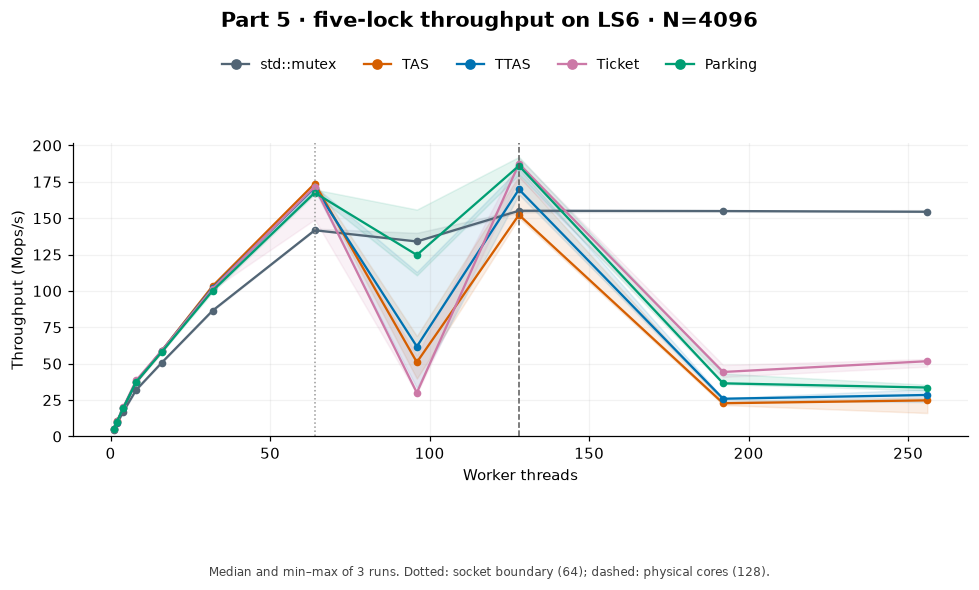

In [3]:
fig,ax=plt.subplots(figsize=(9,5.3))
for lock in P5_LOCKS:
    d=p5[p5.lock==lock];series(ax,d.threads,d['median'],d.low,d.high,LABEL[lock],COL[lock])
boundaries(ax);legend(fig,P5_LOCKS)
finish(fig,'p5_lock_scaling','Part 5 · five-lock throughput on LS6 · N=4096',
       'Median and min–max of 3 runs. Dotted: socket boundary (64); dashed: physical cores (128).')


### Contention counters: separate machines
All counter panels use each file's raw event count divided by that same run's operation count. The LS6 contention measurements have one run per lock; Frontera has three. HITM is a load-side event, not a count of every coherence transfer or every failed atomic operation.

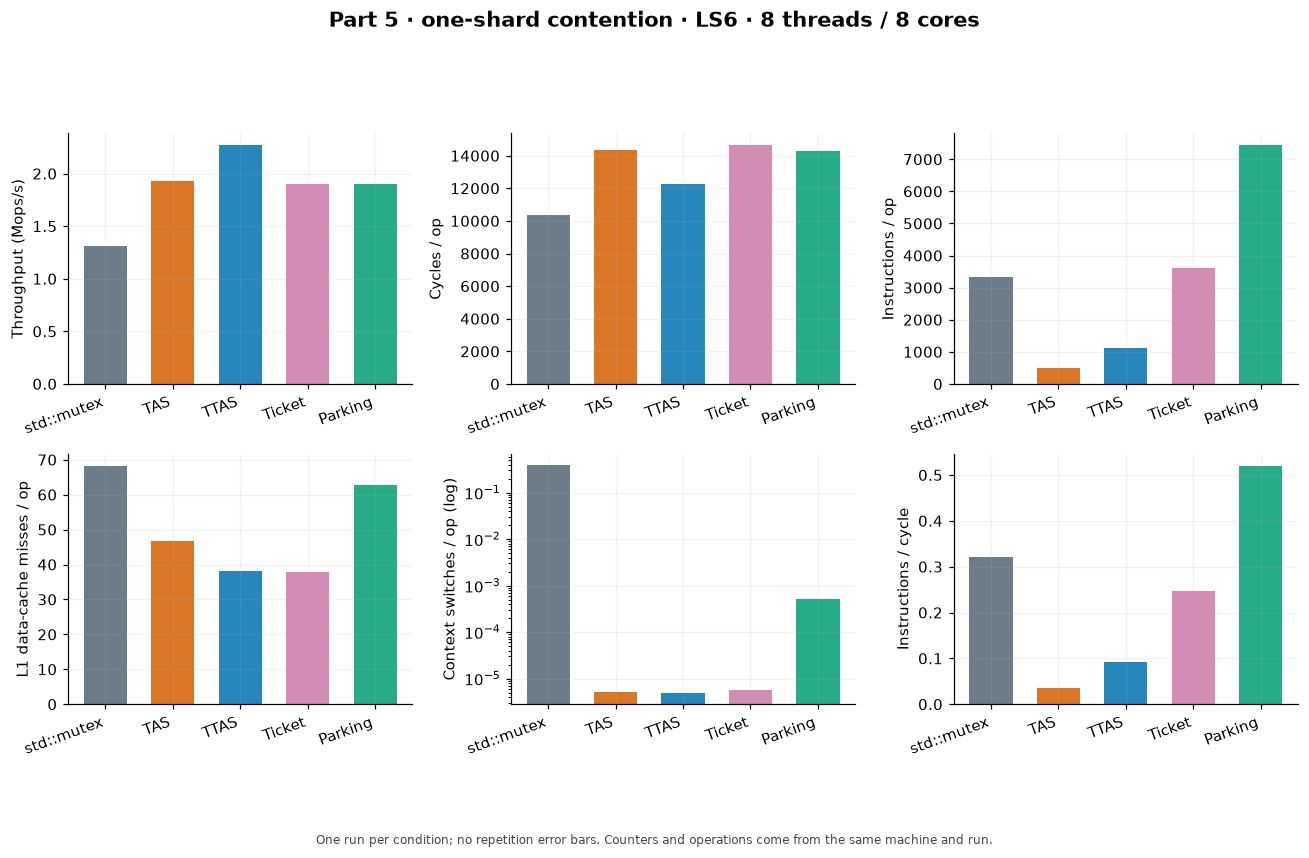

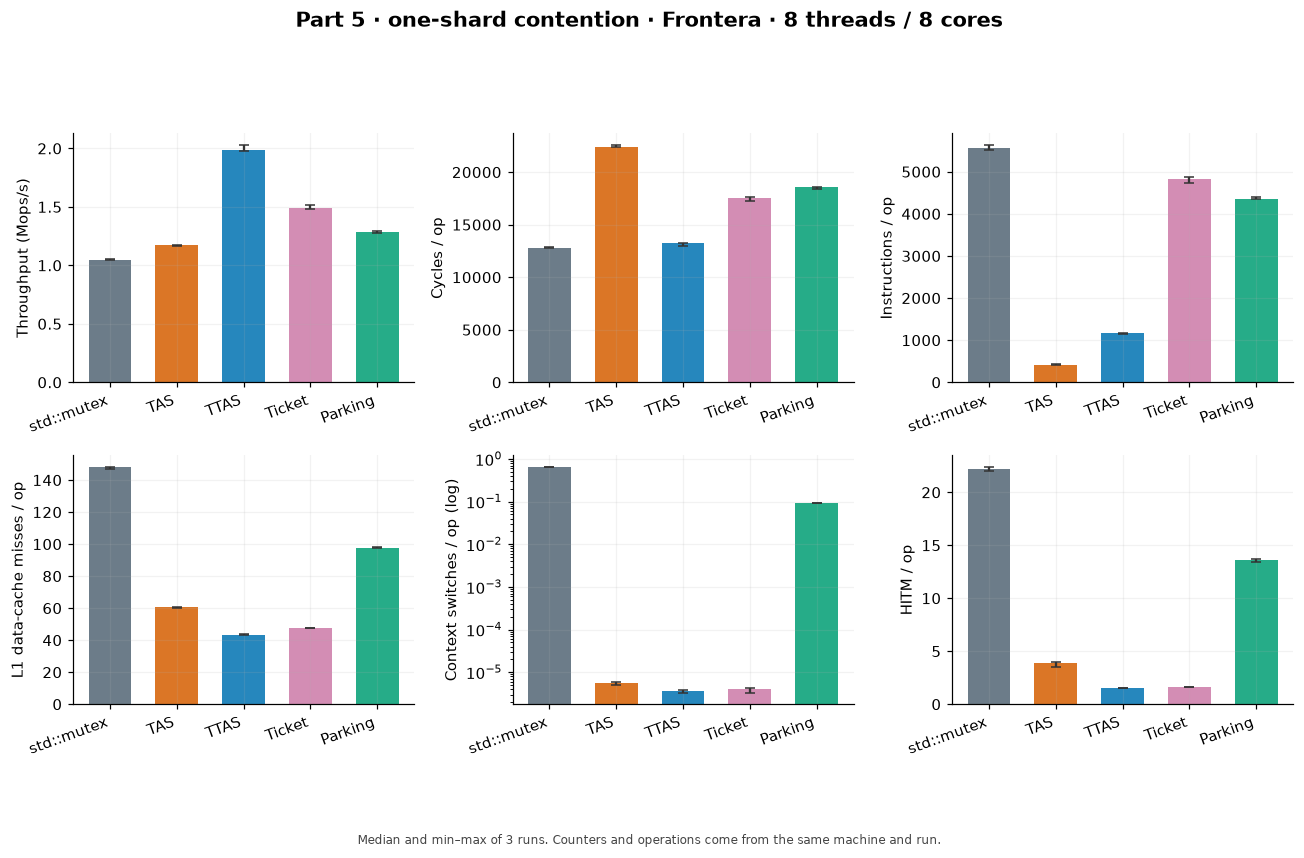

In [4]:
ls6_contention=pd.DataFrame([perf_record(RUN['p5']/f'part5/contention_{l}.txt','LS6')|{'lock':l} for l in P5_LOCKS])
intel_contention=pd.DataFrame([perf_record(RUN['intel']/f'part5/contention_{l}_r{r}.perf.txt','Frontera')|{'lock':l,'repeat':r}
                              for l in P5_LOCKS for r in [1,2,3]])
for df,name in [(ls6_contention,'p5_contention_ls6'),(intel_contention,'p5_contention_frontera')]:table(df,name)

def metric_bars(ax, df, metric, ylabel, locks=P5_LOCKS, log=False):
    for i,lock in enumerate(locks):
        vals=df.loc[df.lock==lock,metric].dropna().to_numpy(); assert len(vals)>0
        med=np.median(vals)
        ax.bar(i,med,color=COL[lock],width=.64,alpha=.85)
        if len(vals)>1:ax.errorbar(i,med,yerr=[[med-vals.min()],[vals.max()-med]],color='0.2',capsize=3,fmt='none')
    ax.set_xticks(range(len(locks)),[LABEL[l] for l in locks],rotation=20,ha='right')
    ax.set_ylabel(ylabel)
    if log:ax.set_yscale('log')
    else:ax.set_ylim(bottom=0)

for df,machine,slug in [(ls6_contention,'LS6','ls6'),(intel_contention,'Frontera','frontera')]:
    metrics=[('mops','Throughput (Mops/s)'),('cycles_per_op','Cycles / op'),('instructions_per_op','Instructions / op'),
             ('L1-dcache-load-misses_per_op','L1 data-cache misses / op'),('context-switches_per_op','Context switches / op (log)'),
             ('mem_load_l3_hit_retired.xsnp_hitm_per_op','HITM / op') if machine=='Frontera' else ('ipc','Instructions / cycle')]
    fig,axs=plt.subplots(2,3,figsize=(12,7.8))
    for ax,(metric,label) in zip(axs.flat,metrics):metric_bars(ax,df,metric,label,log=metric=='context-switches_per_op')
    finish(fig,'p5_contention_'+slug,f'Part 5 · one-shard contention · {machine} · 8 threads / 8 cores',
           ('Median and min–max of 3 runs.' if machine=='Frontera' else 'One run per condition; no repetition error bars.')+' Counters and operations come from the same machine and run.',top=.91,bottom=.10)


### Oversubscription and CPU use
The LS6 follow-up supplies three repetitions per lock at T=32, N=256, CPUs 0–7. Busy fraction uses **task-clock / (8 × perf elapsed time)**; effective GHz uses cycles / task-clock. This avoids assuming the nominal 2.45 GHz. CPU busy time includes spinning, kernel work, and useful work. Approximately 20% hardware-counter running time is retained in the exported table; scaled cycles are not independent confirmation of utilization.

The N=4096 rerun has one counter run per lock and no task-clock. Its counter figure is primary; the N=256 utilization figure is supplemental and must not be presented as N=4096 utilization.

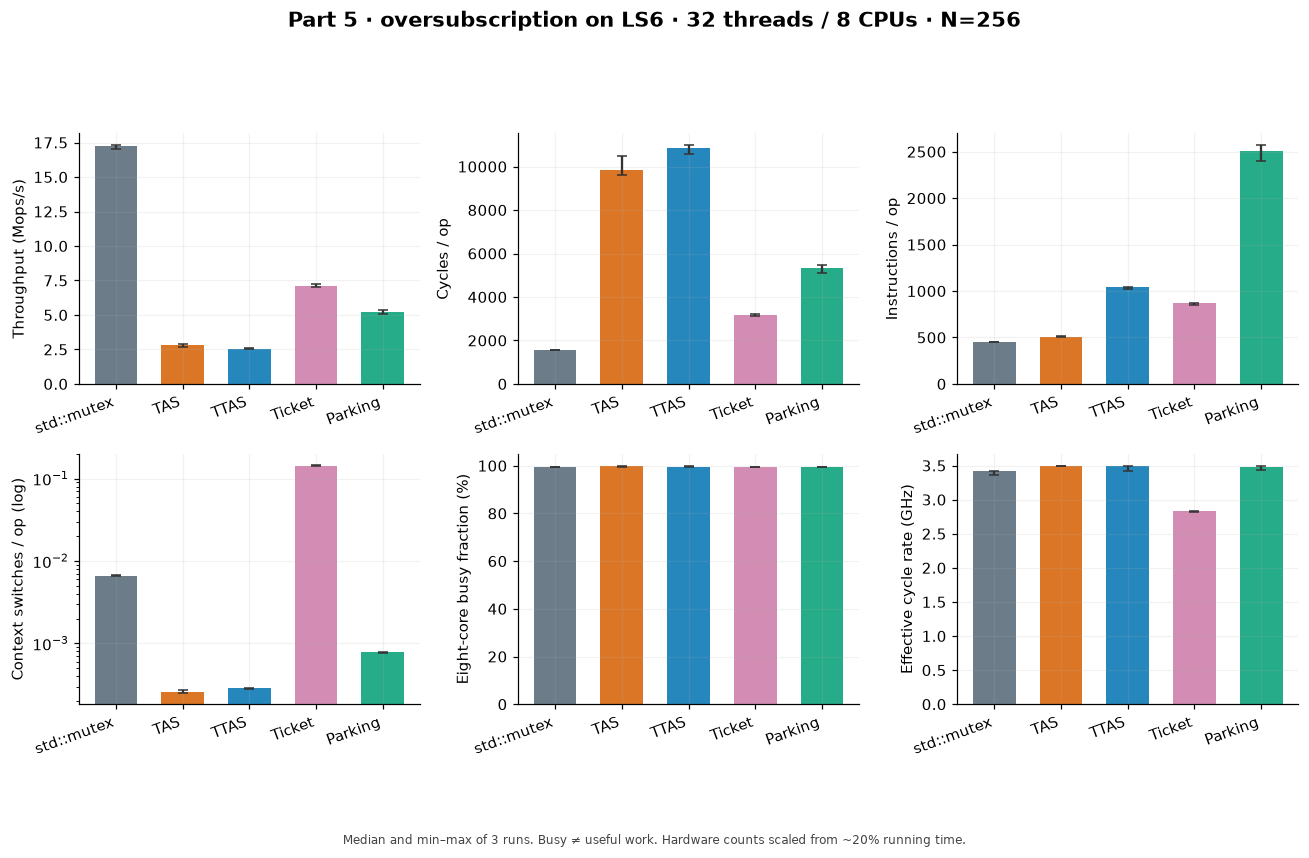

,lock,mops,cycles_per_op,instructions_per_op,context-switches_per_op,busy_pct,effective_ghz
0,mutex,17.237410,1573.690094,446.729427,0.006614,99.497201,3.414936
1,tas,2.819895,9859.909362,501.681484,0.000258,99.675563,3.496650
2,ttas,2.523026,10843.871452,1041.788779,0.000288,99.630218,3.488648
3,ticket,7.119226,3162.702801,866.342350,0.143894,99.620552,2.831186
4,park,5.189602,5327.170955,2512.905621,0.000778,99.609958,3.475856


In [5]:
oversub=pd.DataFrame([perf_record(RUN['followup']/f'part5/oversubscribed_{l}_r{r}.perf.txt','LS6')|{'lock':l,'repeat':r}
                     for l in P5_LOCKS for r in [1,2,3]])
table(oversub,'p5_oversubscription_raw')
metrics=[('mops','Throughput (Mops/s)'),('cycles_per_op','Cycles / op'),('instructions_per_op','Instructions / op'),
         ('context-switches_per_op','Context switches / op (log)'),('busy_pct','Eight-core busy fraction (%)'),('effective_ghz','Effective cycle rate (GHz)')]
fig,axs=plt.subplots(2,3,figsize=(12,7.8))
for ax,(metric,label) in zip(axs.flat,metrics):
    metric_bars(ax,oversub,metric,label,log=metric=='context-switches_per_op')
    if metric=='busy_pct':ax.set_ylim(0,105)
finish(fig,'p5_oversubscription','Part 5 · oversubscription on LS6 · 32 threads / 8 CPUs · N=256',
       'Median and min–max of 3 runs. Busy ≠ useful work. Hardware counts scaled from ~20% running time.',top=.91,bottom=.10)
table(oversub.groupby('lock',sort=False)[[m[0] for m in metrics]].median().reset_index(),'p5_oversubscription_medians')


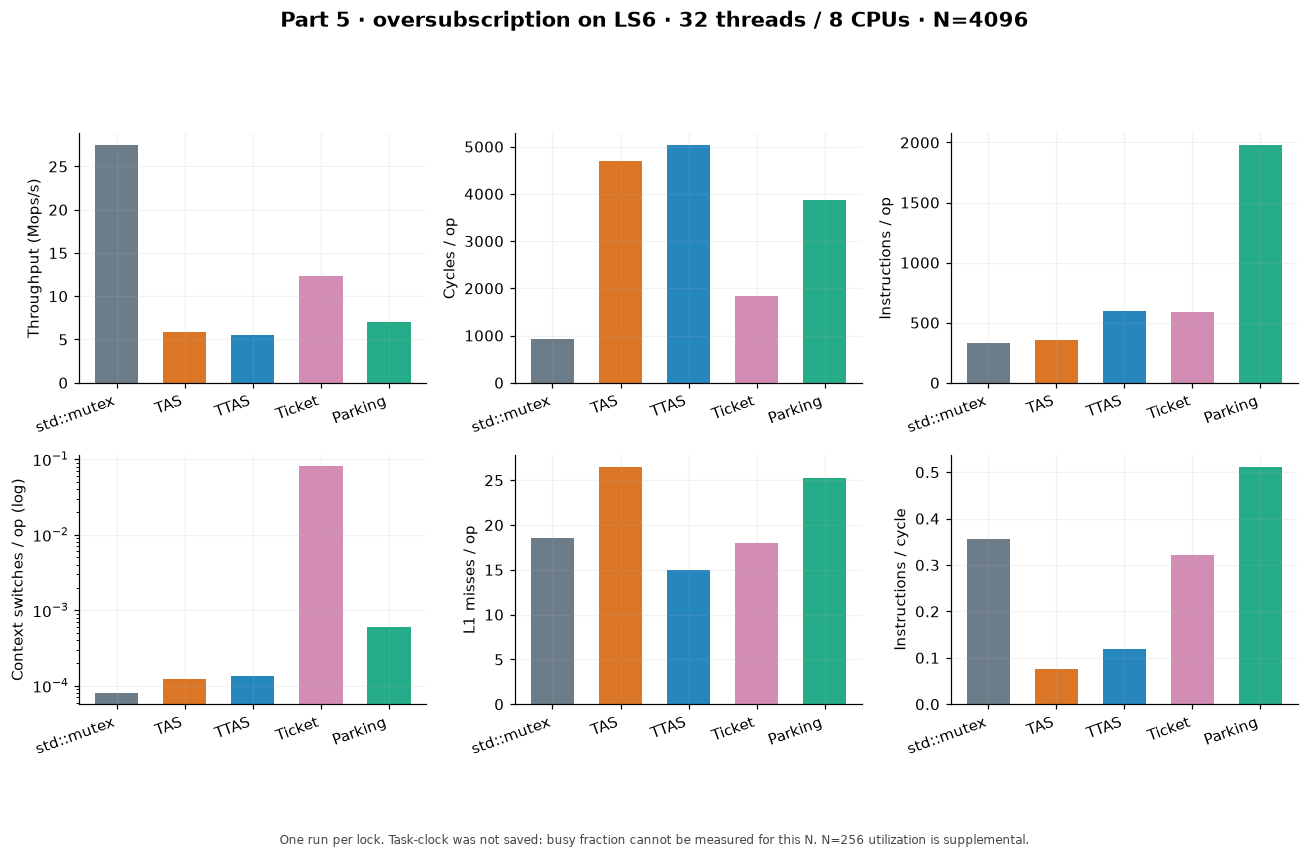

In [6]:
oversub4096=pd.DataFrame([perf_record(RUN['new']/f'part5/oversubscribed_{l}_N4096.txt','LS6')|{'lock':l} for l in P5_LOCKS])
assert set(oversub4096.shards)=={4096}
table(oversub4096,'p5_oversubscription_N4096')
fig,axs=plt.subplots(2,3,figsize=(12,7.8))
for ax,(metric,label) in zip(axs.flat,[
    ('mops','Throughput (Mops/s)'),('cycles_per_op','Cycles / op'),('instructions_per_op','Instructions / op'),
    ('context-switches_per_op','Context switches / op (log)'),('L1-dcache-load-misses_per_op','L1 misses / op'),('ipc','Instructions / cycle')]):
    metric_bars(ax,oversub4096,metric,label,log=metric=='context-switches_per_op')
finish(fig,'p5_oversubscription_N4096','Part 5 · oversubscription on LS6 · 32 threads / 8 CPUs · N=4096',
       'One run per lock. Task-clock was not saved: busy fraction cannot be measured for this N. N=256 utilization is supplemental.',top=.91,bottom=.10)


### Shard choice and collision model
These measurements compare mutex, TTAS, and Parking on the **same follow-up node**. N=4096 remains the main benchmark setting. Faster measured points at larger N do not invalidate those controlled comparisons.

For independent uniform shard choices, an operation shares a shard with another of T choices with probability `1 - (1 - 1/N)^(T-1)`. This model does not measure actual overlapping critical sections. `1000*T/Mops` is an average worker-time estimate in ns/op; it includes computation, scheduling and cache effects, and is **not** an isolated lock-wait or handoff latency.

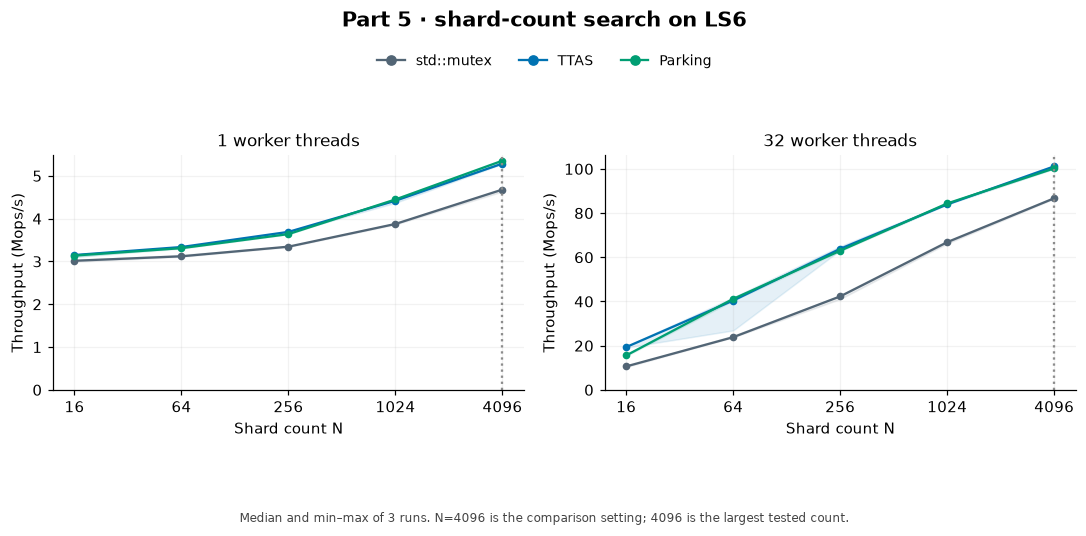

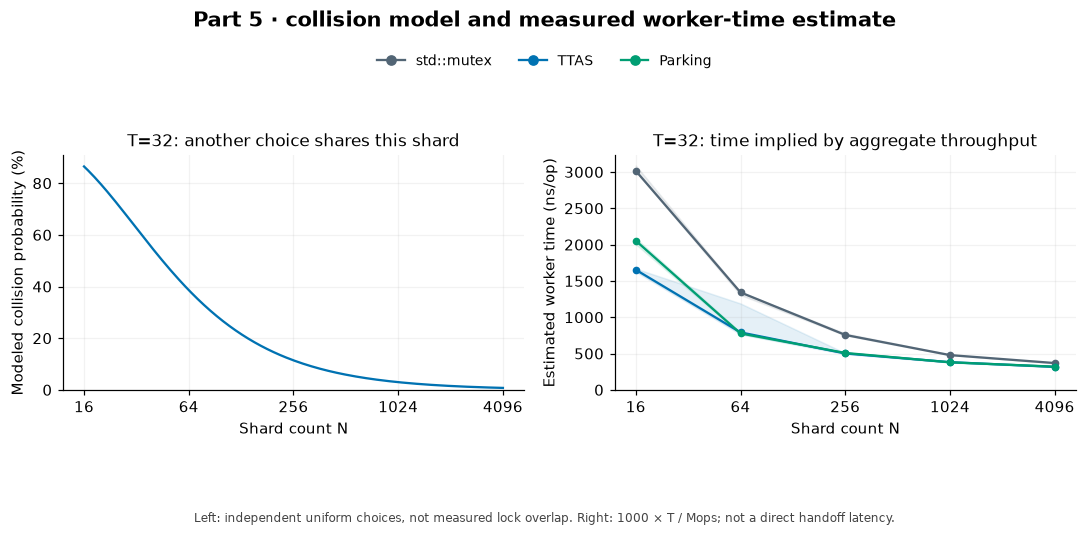

,Build,Check,Outcome
0,Normal TAS,Normal + TSan,Passed (saved validation logs)
1,Relaxed TAS,Ordinary tests,Passed
2,Relaxed TAS,TSan (map and separate lock test),Data race reported (expected experiment)


In [7]:
shard_raw=pd.concat([raw_bench(RUN['followup']/f'part4/shard_counts_{l}.txt').assign(lock=l) for l in ['mutex','ttas','park']],ignore_index=True)
shards=aggregate(shard_raw,['lock','threads','shards']);table(shard_raw,'p5_shard_search_raw');table(shards,'p5_shard_search')
fig,axs=plt.subplots(1,2,figsize=(10,4.8))
for ax,t in zip(axs,[1,32]):
    for lock in ['mutex','ttas','park']:
        d=shards[(shards.lock==lock)&(shards.threads==t)].sort_values('shards')
        series(ax,d.shards,d['median'],d.low,d.high,LABEL[lock],COL[lock])
    ax.set_xscale('log',base=2);ax.set_xticks([16,64,256,1024,4096],labels=['16','64','256','1024','4096'])
    ax.axvline(4096,color='0.55',ls=':');ax.set(title=f'{t} worker threads',xlabel='Shard count N',ylabel='Throughput (Mops/s)',ylim=(0,None))
legend(fig,['mutex','ttas','park'])
finish(fig,'p5_shard_choice','Part 5 · shard-count search on LS6',
       'Median and min–max of 3 runs. N=4096 is the comparison setting; 4096 is the largest tested count.')

fig,axs=plt.subplots(1,2,figsize=(10,4.8))
ns=np.geomspace(16,4096,200);axs[0].plot(ns,100*(1-(1-1/ns)**31),color=COL['ttas'])
axs[0].set(xlabel='Shard count N',ylabel='Modeled collision probability (%)',title='T=32: another choice shares this shard')
for lock in ['mutex','ttas','park']:
    d=shards[(shards.lock==lock)&(shards.threads==32)].sort_values('shards')
    series(axs[1],d.shards,32000/d['median'],32000/d.high,32000/d.low,LABEL[lock],COL[lock])
axs[1].set(xlabel='Shard count N',ylabel='Estimated worker time (ns/op)',title='T=32: time implied by aggregate throughput')
for ax in axs:ax.set_xscale('log',base=2);ax.set_xticks([16,64,256,1024,4096],labels=['16','64','256','1024','4096']);ax.set_ylim(bottom=0)
legend(fig,['mutex','ttas','park'])
finish(fig,'p5_collision_model','Part 5 · collision model and measured worker-time estimate',
       'Left: independent uniform choices, not measured lock overlap. Right: 1000 × T / Mops; not a direct handoff latency.')
collision=shards.copy();collision['modeled_collision_probability']=1-(1-1/collision.shards)**(collision.threads-1)
collision['worker_ns_per_op']=1000*collision.threads/collision['median'];table(collision,'p5_collision_model')

relaxed=RUN['p5']/'part5/relaxed'
assert 'make=0' in read(relaxed/'plain.status') and read(relaxed/'plain.log').count('all checks passed')==2
assert 'data race' in read(relaxed/'tsan.log') and 'data race' in read(relaxed/'locks-tsan.log')
relaxed_table=pd.DataFrame({'Build':['Normal TAS','Relaxed TAS','Relaxed TAS'],
    'Check':['Normal + TSan','Ordinary tests','TSan (map and separate lock test)'],
    'Outcome':['Passed (saved validation logs)','Passed','Data race reported (expected experiment)']})
assert read(RUN['p5']/'test.log').count('all checks passed')==2
assert read(RUN['p5']/'tsan.log').count('all checks passed')==2
display(table(relaxed_table,'p5_relaxed_ordering'))


## Part 6 · readers and writers
Six panels cover all three mixes and both shard counts. Compare curves **within** each panel; y-axis ranges differ. The ratio figure makes the crossover relative to TTAS explicit. A ratio of one is parity; ratios of medians do not establish statistical significance.

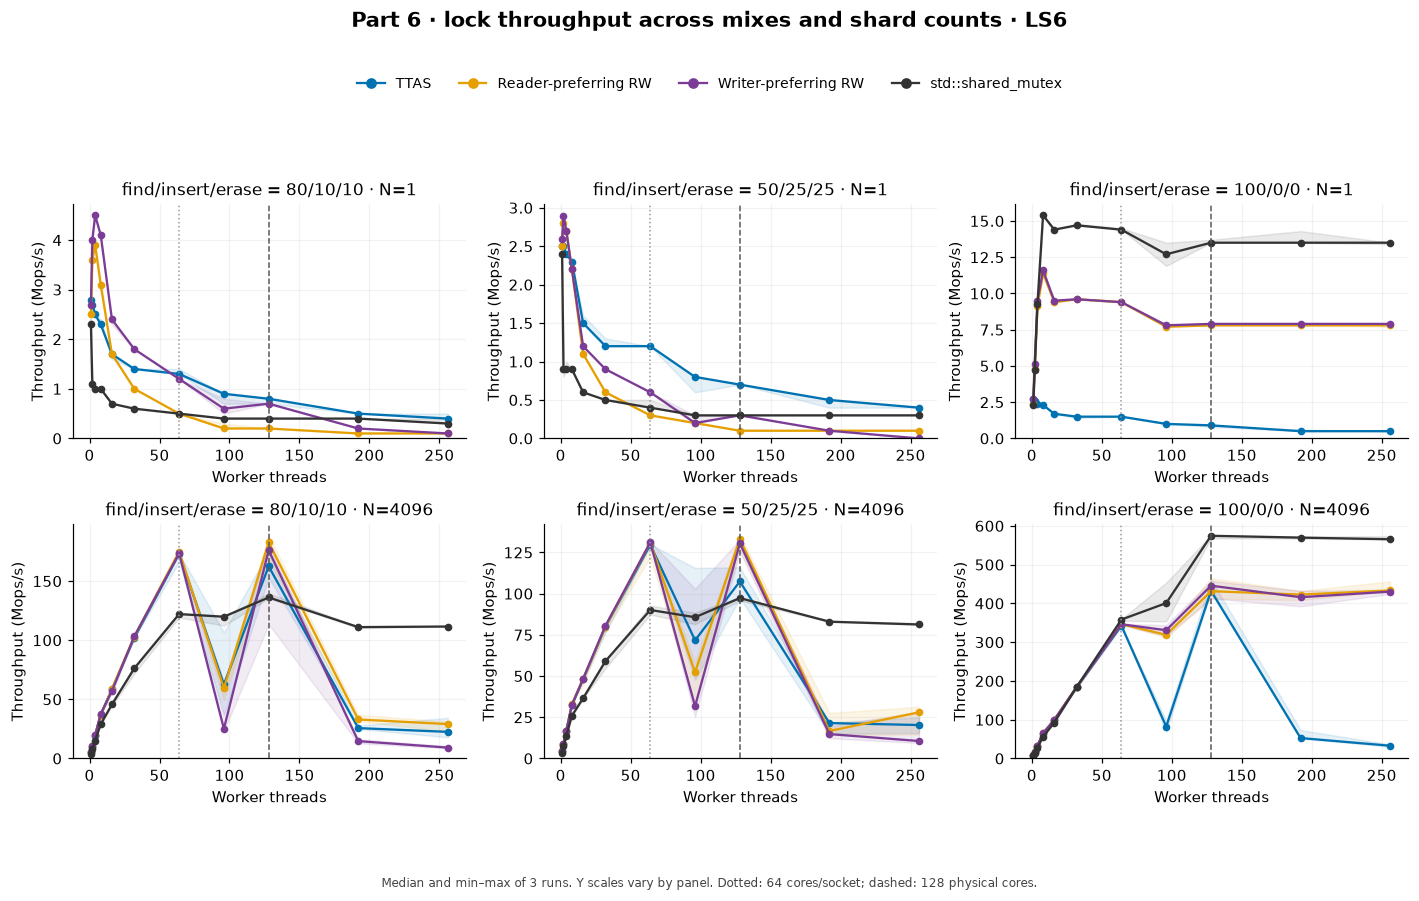

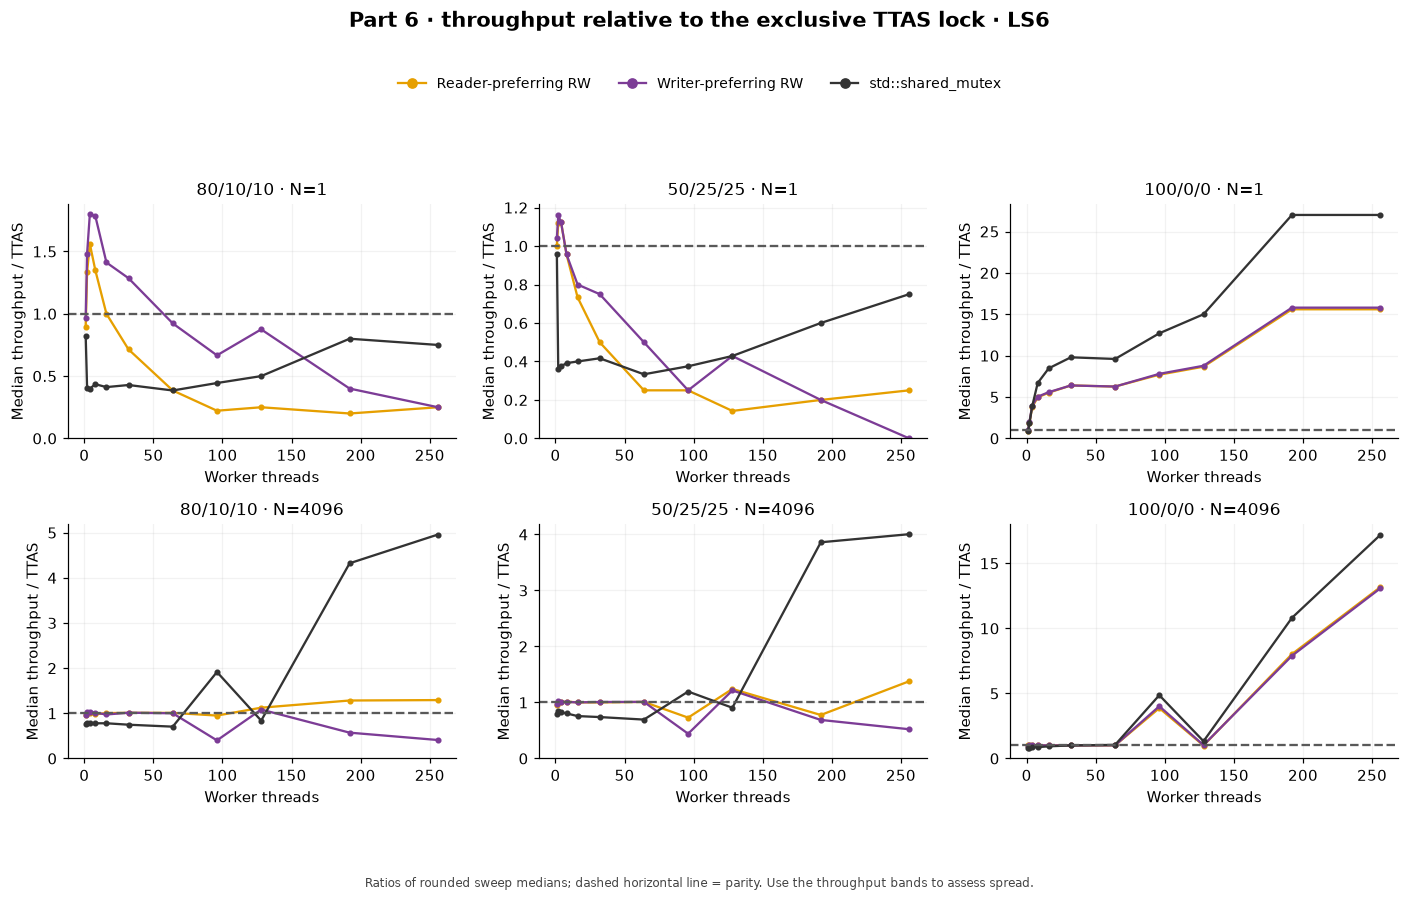

,shards,mix,lock,threads,ratio_to_ttas
0,1,80/10/10,rw,1,0.892857
1,1,80/10/10,rw,2,1.333333
2,1,80/10/10,rw,4,1.560000
3,1,80/10/10,rw,8,1.347826
4,1,80/10/10,rw,16,1.000000
...,...,...,...,...,...
193,4096,100/0/0,shared_mutex,64,1.046423
194,4096,100/0/0,shared_mutex,96,4.865291
195,4096,100/0/0,shared_mutex,128,1.328017
196,4096,100/0/0,shared_mutex,192,10.810247


In [8]:
MIXES=['80/10/10','50/25/25','100/0/0']
fig,axs=plt.subplots(2,3,figsize=(13,8.2))
for i,n in enumerate([1,4096]):
    for j,mix in enumerate(MIXES):
        ax=axs[i,j]
        for lock in P6_LOCKS:
            d=p6[(p6.shards==n)&(p6.mix==mix)&(p6.lock==lock)]
            series(ax,d.threads,d['median'],d.low,d.high,LABEL[lock],COL[lock])
        boundaries(ax);ax.set_title(f'find/insert/erase = {mix} · N={n}')
legend(fig,P6_LOCKS)
finish(fig,'p6_mix_shard_matrix','Part 6 · lock throughput across mixes and shard counts · LS6',
       'Median and min–max of 3 runs. Y scales vary by panel. Dotted: 64 cores/socket; dashed: 128 physical cores.',top=.86,bottom=.09)

ratios=[];fig,axs=plt.subplots(2,3,figsize=(13,8.2))
for i,n in enumerate([1,4096]):
    for j,mix in enumerate(MIXES):
        ax=axs[i,j];base=p6[(p6.shards==n)&(p6.mix==mix)&(p6.lock=='ttas')].set_index('threads')
        for lock in P6_LOCKS[1:]:
            d=p6[(p6.shards==n)&(p6.mix==mix)&(p6.lock==lock)].set_index('threads')
            ratio=d['median']/base['median'].replace(0,np.nan)
            ax.plot(ratio.index,ratio,marker='o',ms=3,label=LABEL[lock],color=COL[lock])
            ratios.extend(dict(shards=n,mix=mix,lock=lock,threads=t,ratio_to_ttas=v) for t,v in ratio.items())
        ax.axhline(1,color='0.35',ls='--');ax.set(title=f'{mix} · N={n}',xlabel='Worker threads',ylabel='Median throughput / TTAS',ylim=(0,None))
legend(fig,P6_LOCKS[1:])
finish(fig,'p6_relative_to_ttas','Part 6 · throughput relative to the exclusive TTAS lock · LS6',
       'Ratios of rounded sweep medians; dashed horizontal line = parity. Use the throughput bands to assess spread.',top=.86,bottom=.09)
table(pd.DataFrame(ratios),'p6_ratios_to_ttas')


### Repeated high-thread-count measurements
Follow-up sweeps repeat 64, 96 and 128 threads at N=256. Solid lines/bands are the follow-up; dashed lines are the primary medians. Keep both datasets: the repeat does not erase the variability in the first run.

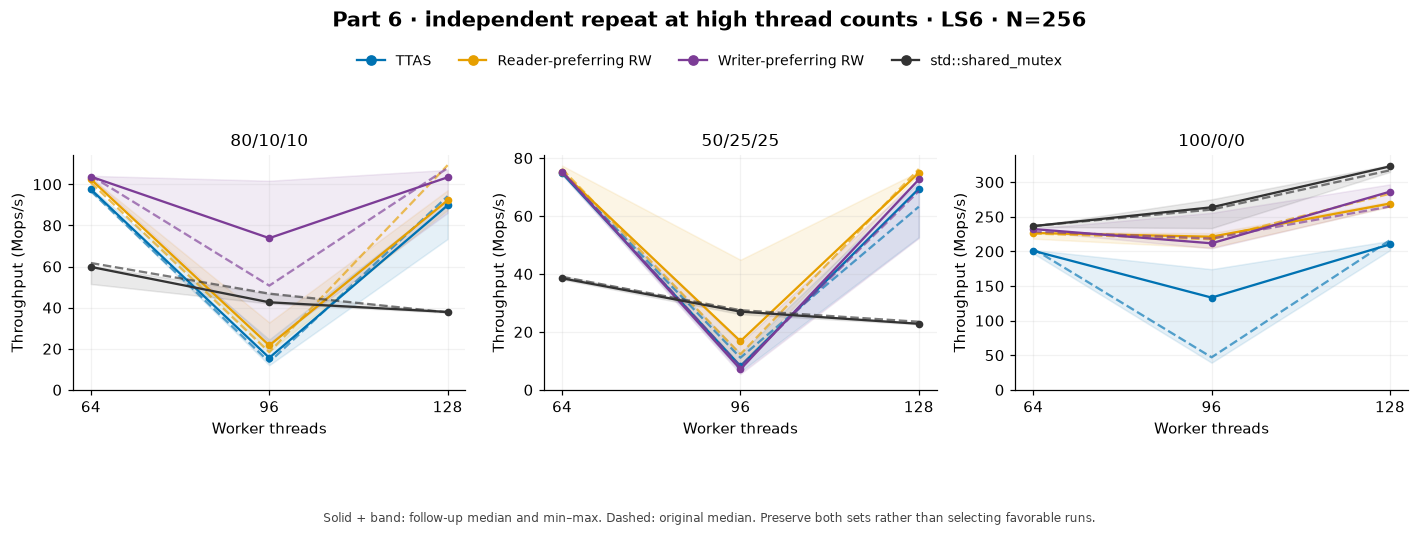

In [9]:
repeat=pd.concat([sweep(RUN['followup']/f'part6-repeat/mix-{mix.replace("/","-")}_shards-256/sharded_{l}.csv').assign(lock=l)
                  for mix in MIXES for l in P6_LOCKS],ignore_index=True)
table(repeat.assign(samples=repeat.samples.map(json.dumps)),'p6_followup_sweeps')
fig,axs=plt.subplots(1,3,figsize=(13,4.8))
for ax,mix in zip(axs,MIXES):
    for lock in P6_LOCKS:
        d=repeat[(repeat.mix==mix)&(repeat.lock==lock)]
        series(ax,d.threads,d['median'],d.low,d.high,LABEL[lock],COL[lock])
        old=p6_legacy[(p6_legacy.mix==mix)&(p6_legacy.lock==lock)&(p6_legacy.shards==256)&p6_legacy.threads.isin([64,96,128])]
        ax.plot(old.threads,old['median'],ls='--',color=COL[lock],alpha=.65)
    ax.set(title=mix,xlabel='Worker threads',ylabel='Throughput (Mops/s)',ylim=(0,None));ax.set_xticks([64,96,128])
legend(fig,P6_LOCKS)
finish(fig,'p6_repeated_points','Part 6 · independent repeat at high thread counts · LS6 · N=256',
       'Solid + band: follow-up median and min–max. Dashed: original median. Preserve both sets rather than selecting favorable runs.')


### Separate reader and writer roles
The user confirmed following the runbook's **4 writers + 28 readers**. The logs record T=32 but do not print the writer count; this configuration is user-confirmed. Reader/writer rates are only printed to 0.1 Mops/s. A printed zero is below resolution; it is not evidence of no progress. Total throughput uses the raw operation count and elapsed time.

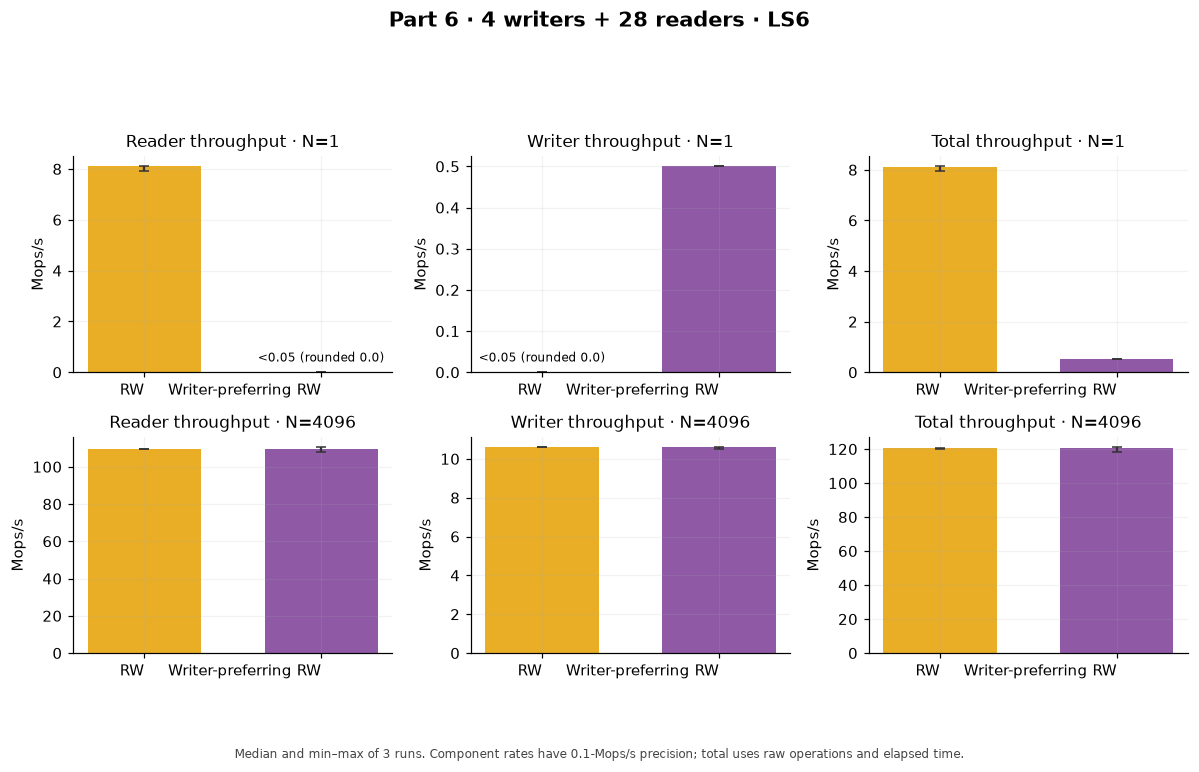

In [10]:
roles=pd.concat([raw_bench((RUN['p7'] if n==1 else RUN['new'])/f'part6/roles_{lock}_shards-{n}.txt').assign(lock=lock)
                 for n in [1,4096] for lock in ['rw','rwp']],ignore_index=True)
table(roles,'p6_roles_raw');fig,axs=plt.subplots(2,3,figsize=(11,7))
for i,n in enumerate([1,4096]):
    for j,(metric,label) in enumerate([('readers','Reader throughput'),('writers','Writer throughput'),('mops','Total throughput')]):
        ax=axs[i,j];df=roles[roles.shards==n]
        metric_bars(ax,df,metric,'Mops/s',locks=['rw','rwp']);ax.set_title(f'{label} · N={n}')
        ax.set_xticks([0,1],['RW','Writer-preferring RW'],rotation=0)
        for k,l in enumerate(['rw','rwp']):
            if metric!='mops' and (df.loc[df.lock==l,metric]==0).all():
                ax.annotate('<0.05 (rounded 0.0)',(k,0),xytext=(0,7),textcoords='offset points',ha='center',fontsize=8)
finish(fig,'p6_reader_writer_roles','Part 6 · 4 writers + 28 readers · LS6',
       'Median and min–max of 3 runs. Component rates have 0.1-Mops/s precision; total uses raw operations and elapsed time.',top=.90,bottom=.10)


## Part 7 · buckets and chain length
The one-thread tree baseline and hash-table bucket search both use 4096 shards/stripes. Throughput comes from the short, three-repeat runs; counters come from separate 20-second runs. Their rates can differ.

Mean chain length is approximated as **524,288 resident entries / B**, not the one-million-key universe / B. Occupancy is not sampled in the logs. Regressions below describe the measurements; they are not pre-measurement predictions or causal estimates of isolated memory latency.

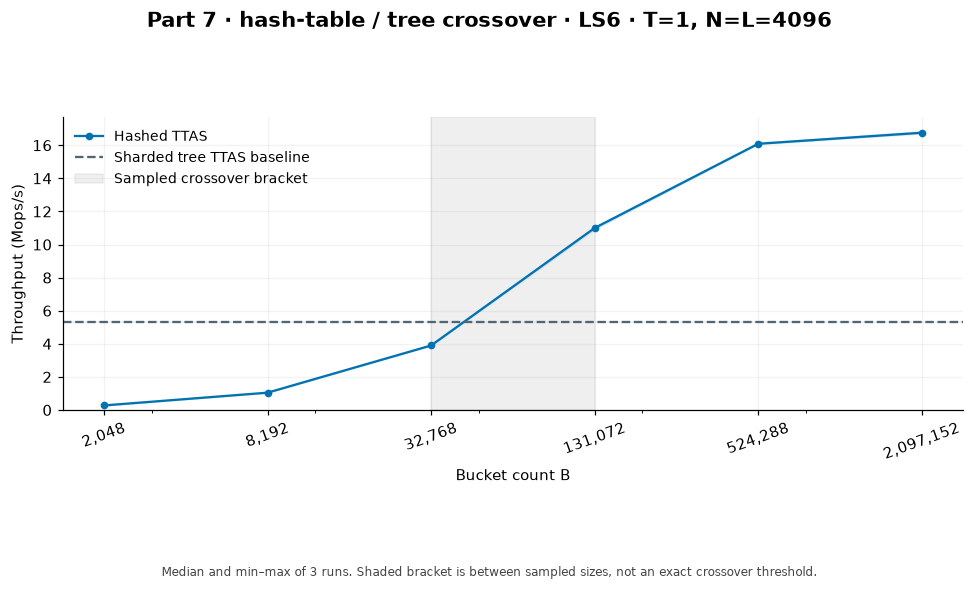

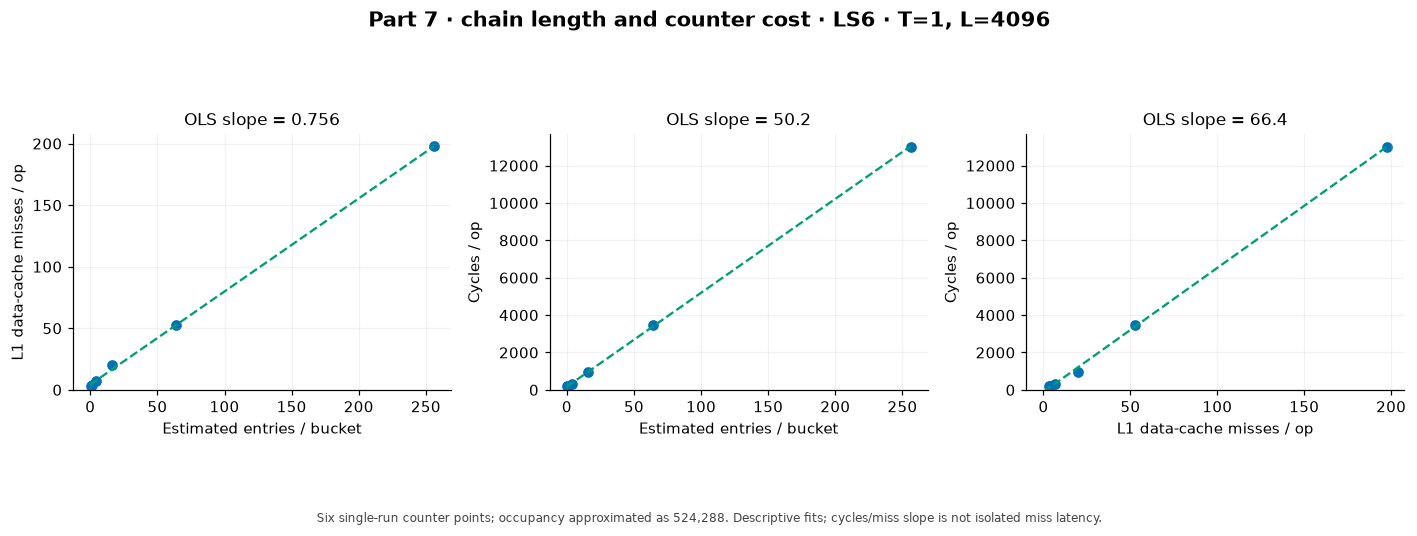

,x,y,slope,intercept,points
0,mean_chain_estimate,L1-dcache-load-misses_per_op,0.755791,4.313540,6
1,mean_chain_estimate,cycles_per_op,50.236251,171.277405,6
2,L1-dcache-load-misses_per_op,cycles_per_op,66.425742,-113.417833,6


In [11]:
BUCKETS=[2048,8192,32768,131072,524288,2097152]
bucket_raw=pd.concat([raw_bench(RUN['new']/f'part7/buckets_{b}_N4096.txt').assign(buckets=b) for b in BUCKETS],ignore_index=True)
buckets=aggregate(bucket_raw,['buckets']);tree=raw_bench(RUN['new']/'part7/tree_baseline_N4096.txt')
bucket_perf=pd.DataFrame([perf_record(RUN['new']/f'part7/buckets_{b}_N4096_perf.txt','LS6')|{'buckets':b} for b in BUCKETS])
bucket_perf['mean_chain_estimate']=524288/bucket_perf.buckets
for df,name in [(bucket_raw,'p7_bucket_raw'),(buckets,'p7_bucket_summary'),(tree,'p7_tree_baseline'),(bucket_perf,'p7_bucket_counters')]:table(df,name)
fig,ax=plt.subplots(figsize=(9,5.3))
series(ax,buckets.buckets,buckets['median'],buckets.low,buckets.high,'Hashed TTAS',COL['ttas'])
tm=tree.mops.median();ax.axhline(tm,color=COL['mutex'],ls='--',label='Sharded tree TTAS baseline')
ax.axhspan(tree.mops.min(),tree.mops.max(),color=COL['mutex'],alpha=.13)
below=buckets[buckets['median']<tm].buckets
above=buckets[buckets['median']>=tm].buckets
assert len(below) and len(above), 'Crossover not bracketed by saved sizes'
bracket=(below.max(), above.min())
assert bracket[0]<bracket[1]
ax.axvspan(*bracket,color='0.8',alpha=.3,label='Sampled crossover bracket')
ax.set_xscale('log',base=4);ax.set_xticks(BUCKETS,labels=[f'{b:,}' for b in BUCKETS],rotation=20)
ax.set(xlabel='Bucket count B',ylabel='Throughput (Mops/s)',ylim=(0,None));ax.legend(frameon=False,fontsize=9)
finish(fig,'p7_bucket_crossover','Part 7 · hash-table / tree crossover · LS6 · T=1, N=L=4096',
       'Median and min–max of 3 runs. Shaded bracket is between sampled sizes, not an exact crossover threshold.',top=.90)

fig,axs=plt.subplots(1,3,figsize=(13,4.8));fits=[]
for ax,xcol,ycol,xlabel,ylabel in [
    (axs[0],'mean_chain_estimate','L1-dcache-load-misses_per_op','Estimated entries / bucket','L1 data-cache misses / op'),
    (axs[1],'mean_chain_estimate','cycles_per_op','Estimated entries / bucket','Cycles / op'),
    (axs[2],'L1-dcache-load-misses_per_op','cycles_per_op','L1 data-cache misses / op','Cycles / op')]:
    x=bucket_perf[xcol].to_numpy();y=bucket_perf[ycol].to_numpy();slope,intercept=np.polyfit(x,y,1)
    xx=np.linspace(0,x.max(),200);ax.scatter(x,y,color=COL['ttas']);ax.plot(xx,slope*xx+intercept,color=COL['park'],ls='--')
    ax.set(xlabel=xlabel,ylabel=ylabel,title=f'OLS slope = {slope:.3g}');ax.set_ylim(bottom=0)
    fits.append(dict(x=xcol,y=ycol,slope=slope,intercept=intercept,points=len(x)))
finish(fig,'p7_chain_length','Part 7 · chain length and counter cost · LS6 · T=1, L=4096',
       'Six single-run counter points; occupancy approximated as 524,288. Descriptive fits; cycles/miss slope is not isolated miss latency.',top=.90)
display(table(pd.DataFrame(fits),'p7_descriptive_fits'))


### Stripe-count choice
The bucket count stays at the default 2,097,152 while stripe count varies. T=1 exposes uncontended overhead and T=32 exposes concurrent behavior. The search ends at 4096, so the best measured point is not proof of a global optimum.

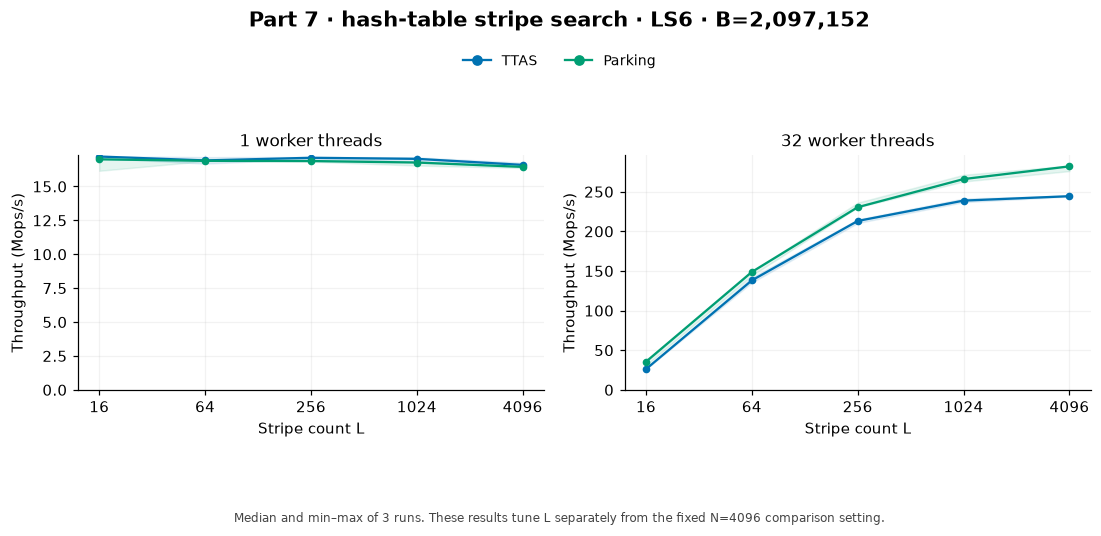

In [12]:
stripe_raw=pd.concat([raw_bench(RUN['p7']/f'part7/stripe_counts_{l}.txt').assign(lock=l) for l in ['ttas','park']],ignore_index=True)
stripes=aggregate(stripe_raw,['lock','threads','shards']);table(stripe_raw,'p7_stripe_raw');table(stripes,'p7_stripe_summary')
fig,axs=plt.subplots(1,2,figsize=(10,4.8))
for ax,t in zip(axs,[1,32]):
    for lock in ['ttas','park']:
        d=stripes[(stripes.lock==lock)&(stripes.threads==t)].sort_values('shards')
        series(ax,d.shards,d['median'],d.low,d.high,LABEL[lock],COL[lock])
    ax.set_xscale('log',base=2);ax.set_xticks([16,64,256,1024,4096],labels=['16','64','256','1024','4096'])
    ax.set(title=f'{t} worker threads',xlabel='Stripe count L',ylabel='Throughput (Mops/s)',ylim=(0,None))
legend(fig,['ttas','park'])
finish(fig,'p7_stripe_choice','Part 7 · hash-table stripe search · LS6 · B=2,097,152',
       'Median and min–max of 3 runs. These results tune L separately from the fixed N=4096 comparison setting.')


### Padding throughput and effect size
Both families use 1024 shards/stripes. Hashed stripe locks are 1 byte unpadded on this compiler (up to 64 per 64-byte cache line); sharded objects also contain map metadata, so that lock density does not apply to them. Hash size counters occupy separate padded cache lines in this source version.

The speedup envelopes below are `[min(padded)/max(unpadded), max(padded)/min(unpadded)]`, **not confidence intervals or paired-run ratios**. Use the exported table to identify both the largest absolute and relative differences.

TTASLock size=1 alignment=1 CACHE_LINE=64


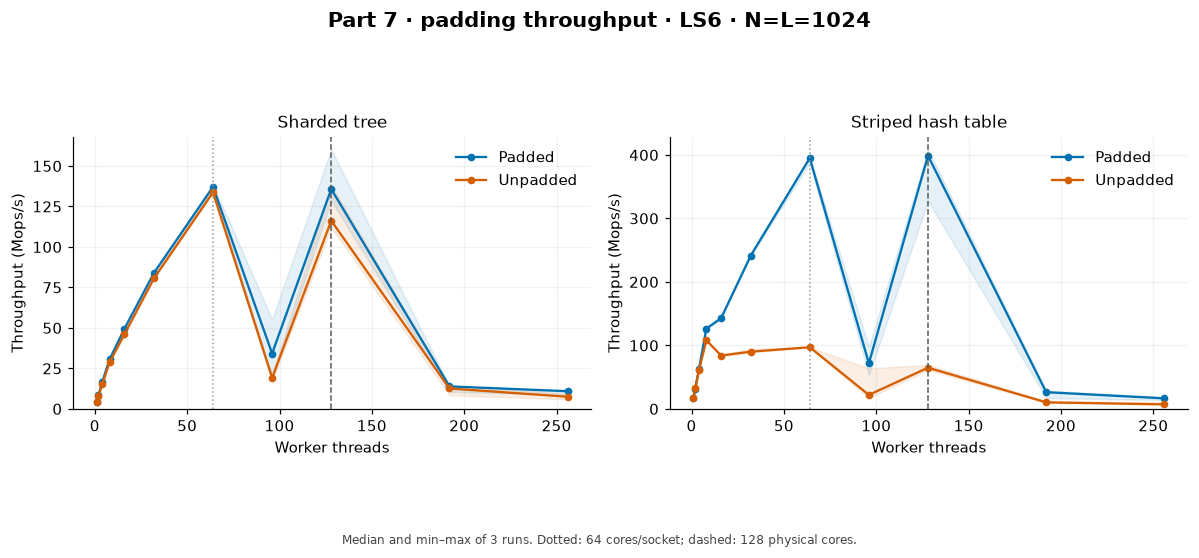

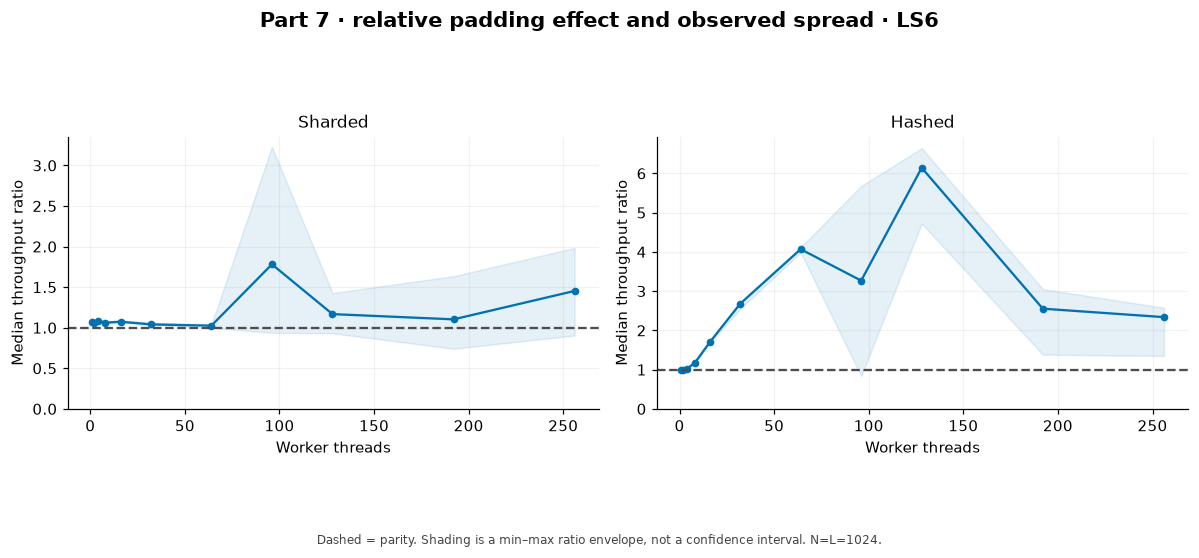

,family,threads,absolute_gain_mops,ratio,range_low,range_high,observed_ranges_overlap
19,hashed,128,333.8,6.143297,4.720461,6.642276,False
8,sharded,128,19.5,1.167814,0.931884,1.427807,True


In [13]:
print(read(RUN['p7']/'part7/lock_size.txt').strip())
fig,axs=plt.subplots(1,2,figsize=(11,5))
for ax,family in zip(axs,['sharded','hashed']):
    for padded,color in [(True,COL['ttas']),(False,COL['tas'])]:
        d=padding[(padding.family==family)&(padding.padded==padded)]
        series(ax,d.threads,d['median'],d.low,d.high,'Padded' if padded else 'Unpadded',color)
    boundaries(ax);ax.set_title('Sharded tree' if family=='sharded' else 'Striped hash table');ax.legend(frameon=False)
finish(fig,'p7_padding_throughput','Part 7 · padding throughput · LS6 · N=L=1024',
       'Median and min–max of 3 runs. Dotted: 64 cores/socket; dashed: 128 physical cores.',top=.90)

effects=[];fig,axs=plt.subplots(1,2,figsize=(11,5))
for ax,family in zip(axs,['sharded','hashed']):
    a=padding[(padding.family==family)&padding.padded].set_index('threads')
    b=padding[(padding.family==family)&~padding.padded].set_index('threads')
    ratio=a['median']/b['median'];lo=a.low/b.high;hi=a.high/b.low
    series(ax,a.index,ratio,lo,hi,'Padded / unpadded',COL['ttas'])
    ax.axhline(1,color='0.3',ls='--');ax.set(title=family.capitalize(),xlabel='Worker threads',ylabel='Median throughput ratio',ylim=(0,None))
    for t in a.index:effects.append(dict(family=family,threads=t,absolute_gain_mops=a.loc[t,'median']-b.loc[t,'median'],ratio=ratio[t],range_low=lo[t],range_high=hi[t],observed_ranges_overlap=max(a.loc[t,'low'],b.loc[t,'low'])<=min(a.loc[t,'high'],b.loc[t,'high'])))
finish(fig,'p7_padding_effect','Part 7 · relative padding effect and observed spread · LS6',
       'Dashed = parity. Shading is a min–max ratio envelope, not a confidence interval. N=L=1024.',top=.90)
effects=pd.DataFrame(effects);table(effects,'p7_padding_effect')
display(effects.loc[effects.groupby('family').absolute_gain_mops.idxmax()])


### Padding counters: keep machines separate
Frontera has three repetitions at T=28, L=1024 on one socket. LS6 has one run per padding configuration. **The faster padded hash table has higher measured load-HITM/op in the Frontera data.** Show this result as observed: it does not support a claim that padding reduced this particular counter. The counter includes all qualifying loads, not just accesses to the lock word.

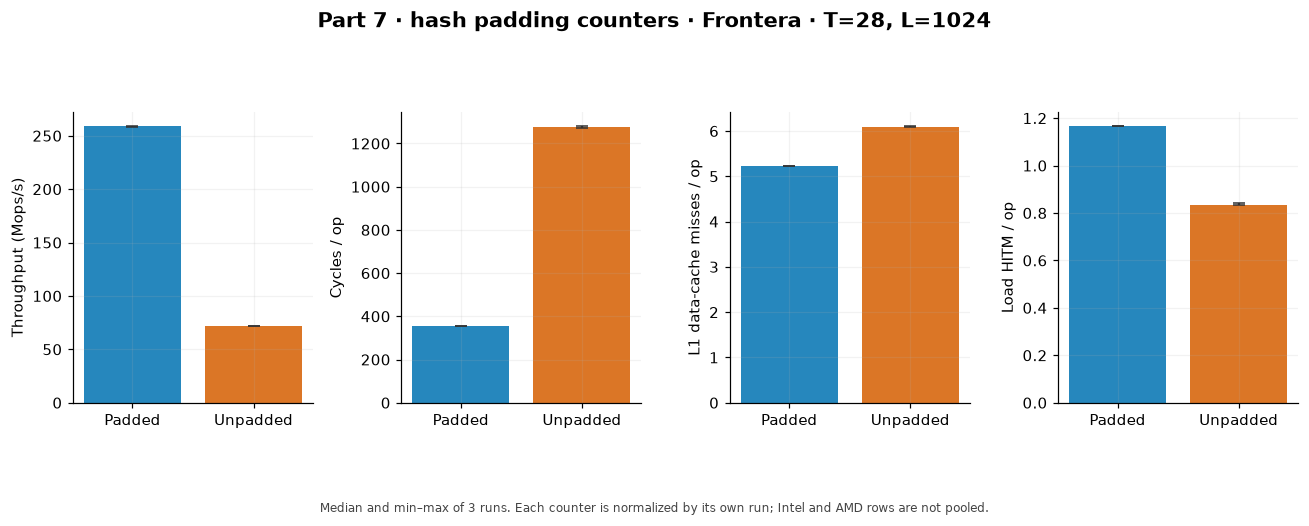

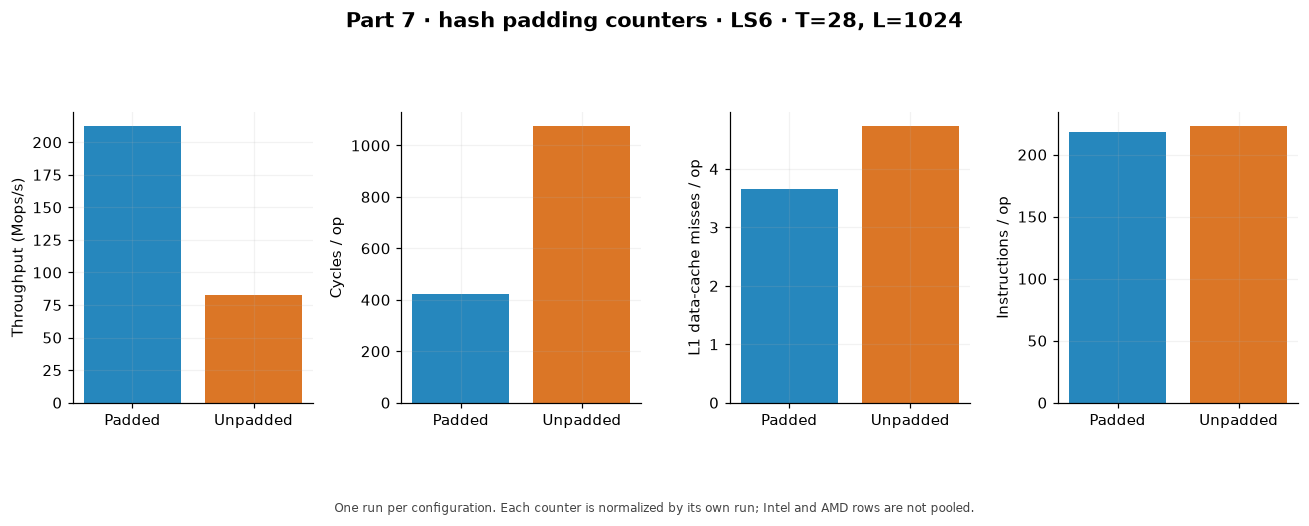

In [14]:
intel_padding=pd.DataFrame([perf_record(RUN['intel']/f'part7/hashed_ttas{suffix}_r{r}.perf.txt','Frontera')|{'variant':'Unpadded' if suffix else 'Padded','repeat':r}
                           for suffix in ['', '_nopad'] for r in [1,2,3]])
ls6_padding=pd.DataFrame([perf_record(RUN['p7']/f'part7/hashed_ttas{suffix}_padding_perf.txt','LS6')|{'variant':'Unpadded' if suffix else 'Padded'}
                         for suffix in ['', '_nopad']])
for df,machine,slug in [(intel_padding,'Frontera','frontera'),(ls6_padding,'LS6','ls6')]:
    table(df,'p7_padding_counters_'+slug)
    metrics=[('mops','Throughput (Mops/s)'),('cycles_per_op','Cycles / op'),('L1-dcache-load-misses_per_op','L1 data-cache misses / op'),
             ('mem_load_l3_hit_retired.xsnp_hitm_per_op','Load HITM / op') if machine=='Frontera' else ('instructions_per_op','Instructions / op')]
    fig,axs=plt.subplots(1,4,figsize=(12,4.7))
    for ax,(metric,label) in zip(axs,metrics):
        for i,(variant,color) in enumerate([('Padded',COL['ttas']),('Unpadded',COL['tas'])]):
            vals=df.loc[df.variant==variant,metric].to_numpy();med=np.median(vals)
            ax.bar(i,med,color=color,alpha=.85)
            if len(vals)>1:ax.errorbar(i,med,yerr=[[med-vals.min()],[vals.max()-med]],fmt='none',color='0.2',capsize=4)
        ax.set_xticks([0,1],['Padded','Unpadded']);ax.set_ylabel(label);ax.set_ylim(bottom=0)
    finish(fig,'p7_padding_counters_'+slug,f'Part 7 · hash padding counters · {machine} · T=28, L=1024',
           ('Median and min–max of 3 runs.' if machine=='Frontera' else 'One run per configuration.')+' Each counter is normalized by its own run; Intel and AMD rows are not pooled.',top=.90)


## Export checks and reproducibility
The notebook exports the exact source paths and SHA-256 digests it used, a figure index, raw parsed tables, and per-condition summaries. No benchmark source or measurement file is changed. Re-running overwrites only this notebook's generated `analysis/figures/` and `analysis/tables/` outputs.

**Report selection:** the assignment has an eight-page total limit. Use selected multi-panel figures; keep supporting panels and CSV tables as supplementary analysis. Do not force every exported plot into the report. Core plots are `p5_lock_scaling`, `p5_shard_choice`, `p6_mix_shard_matrix`, `p6_reader_writer_roles`, `p7_bucket_crossover`, `p7_chain_length`, `p7_stripe_choice`, and `p7_padding_throughput`; counter panels/tables supply the accompanying evidence.

In [15]:
for df,name,key in [(ls6_contention,'p5_contention_ls6_summary','lock'),
                    (intel_contention,'p5_contention_frontera_summary','lock'),
                    (oversub,'p5_oversubscription_summary','lock'),
                    (intel_padding,'p7_padding_frontera_summary','variant'),
                    (ls6_padding,'p7_padding_ls6_summary','variant')]:
    metrics=[x for x in df.columns if x.endswith('_per_op') or x in ['mops','ipc','busy_pct','effective_ghz']]
    summary=df.groupby(key,sort=False)[metrics].agg(['median','min','max'])
    summary.columns=['_'.join(x) for x in summary.columns]
    table(summary.reset_index(),name)
table(pd.DataFrame([{'path':p,'sha256':h} for p,h in sorted(used.items())]),'source_inventory')
table(pd.DataFrame(figure_index),'figure_index')
versions={p:importlib.metadata.version(p) for p in ['numpy','pandas','matplotlib','nbformat','nbclient','ipykernel']}
(TAB/'environment.json').write_text(json.dumps(versions,indent=2)+'\n')
assert len(figure_index)==18, len(figure_index)
assert len(p5)==55 and len(p6)==264 and len(padding)==44
assert len(oversub)==15 and len(intel_contention)==15 and len(intel_padding)==6
assert len(shard_raw)==90 and len(stripe_raw)==60 and len(roles)==12
for rec in figure_index:
    for ext in ['pdf','svg','png']:assert (FIG/(rec['figure']+'.'+ext)).stat().st_size>0
print(f'Completed: {len(figure_index)} figures × 3 formats, {len(list(TAB.glob("*.csv")))} CSV tables.')
display(pd.DataFrame(figure_index)[['figure','title']])


Completed: 18 figures × 3 formats, 34 CSV tables.


,figure,title
0,p5_lock_scaling,Part 5 · five-lock throughput on LS6 · N=4096
1,p5_contention_ls6,Part 5 · one-shard contention · LS6 · 8 thread...
2,p5_contention_frontera,Part 5 · one-shard contention · Frontera · 8 t...
3,p5_oversubscription,Part 5 · oversubscription on LS6 · 32 threads ...
4,p5_oversubscription_N4096,Part 5 · oversubscription on LS6 · 32 threads ...
5,p5_shard_choice,Part 5 · shard-count search on LS6
6,p5_collision_model,Part 5 · collision model and measured worker-t...
7,p6_mix_shard_matrix,Part 6 · lock throughput across mixes and shar...
8,p6_relative_to_ttas,Part 6 · throughput relative to the exclusive ...
9,p6_repeated_points,Part 6 · independent repeat at high thread cou...
